In [1]:
library(ggplot2)
library(ggpubr)
library(Seurat)
library(ComplexHeatmap)
library(colorRamps)
library(circlize) 
library(dplyr)
library(scales)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: 'SeuratObject'


The following objects are masked from 'package:base':

    intersect, t


Loading required package: grid

ComplexHeatmap version 2.20.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github pag

In [ ]:
droprds<-readRDS("drop.rds")
droprds=subset(droprds,total_UMI>1000)
dropletlevel<-droprds@meta.data[,c("orig.ident","cell_barcode","GRCh38","GRCm39")]
colnames(dropletlevel)<-c("roundTow_index","roundOne_index","GRCh38","GRCm39")
dropletlevel$GRCh38_w=as.numeric(dropletlevel$GRCh38/1000)
dropletlevel$GRCm39_w=as.numeric(dropletlevel$GRCm39/1000)
dropletlevel$total_UMI=dropletlevel$GRCh38+dropletlevel$GRCm39
dropletlevel$total_UMI_w=as.numeric(dropletlevel$total_UMI/1000)
dropletlevel$ratio=dropletlevel$GRCh38/dropletlevel$total_UMI
umicols=c('#ccece6','#238b45','#006d2c','#00441b')
p1=ggscatter(dropletlevel,x="GRCm39_w",y="GRCh38_w",
            size=1,alpha=0.7,
            shape = 16,
            color = "total_UMI",
            ylab="Human genome (UMI counts x 1000)",
            xlab="Mouse genome (UMI counts x 1000)",
            legend="right")+ggtitle("Only round one index")+ggthemes::theme_few()+ 
  scale_color_gradientn(
    colours = umicols,
    name    = "UMI counts (x1000)",
    oob     = squish
  )


                   roundTow_index     roundOne_index GRCh38 GRCm39 GRCh38_w
AAACCTGAGAGCCCAA-1        Droplet AAACCTGAGAGCCCAA-1   1056  11697    1.056
AAACCTGAGCTAGTTC-1        Droplet AAACCTGAGCTAGTTC-1  10744    181   10.744
AAACCTGAGCTGAACG-1        Droplet AAACCTGAGCTGAACG-1   8090    291    8.090
AAACCTGAGGAGTTTA-1        Droplet AAACCTGAGGAGTTTA-1    866    206    0.866
AAACCTGAGTCTCCTC-1        Droplet AAACCTGAGTCTCCTC-1   5342  10276    5.342
AAACCTGCAAGTTCTG-1        Droplet AAACCTGCAAGTTCTG-1   9386    393    9.386
                   GRCm39_w total_UMI total_UMI_w      ratio
AAACCTGAGAGCCCAA-1   11.697     12753      12.753 0.08280405
AAACCTGAGCTAGTTC-1    0.181     10925      10.925 0.98343249
AAACCTGAGCTGAACG-1    0.291      8381       8.381 0.96527861
AAACCTGAGGAGTTTA-1    0.206      1072       1.072 0.80783582
AAACCTGAGTCTCCTC-1   10.276     15618      15.618 0.34204123
AAACCTGCAAGTTCTG-1    0.393      9779       9.779 0.95981184


In [ ]:
## cell levels
hsmat<-hsdat@meta.data[,c("orig.ident","cell_barcode","GRCh38","GRCm39")]
colnames(hsmat)<-c("roundTow_index","roundOne_index","GRCh38","GRCm39")
msmat<-mous@meta.data[,c("orig.ident","cell_barcode","GRCh38","GRCm39")]
colnames(msmat)<-c("roundTow_index","roundOne_index","GRCh38","GRCm39")
celldat<-rbind(hsmat,msmat)
celldat$GRCh38_w=as.numeric(celldat$GRCh38/1000)
celldat$GRCm39_w=as.numeric(celldat$GRCm39/1000)
celldat$total_UMI=celldat$GRCh38+celldat$GRCm39
celldat$total_UMI_w=as.numeric(celldat$total_UMI/1000)
celldat$ratio=celldat$GRCh38/celldat$GRCm39
celldat$ratio=celldat$GRCh38/celldat$total_UMI
celldat=subset(celldat,total_UMI>1000)
p2=ggscatter(celldat,x="GRCm39_w",y="GRCh38_w",
            size=1,alpha=0.7,
            shape = 16,
            color = "total_UMI",
            ylab="Human genome (UMI counts x 1000)",
            xlab="Mouse genome (UMI counts x 1000)",
            legend="right")+ggtitle("Both index1 and index2")+ggthemes::theme_few()+ 
  scale_color_gradientn(
    colours = umicols,
    name    = "UMI counts (1000)",
    oob     = squish
  )


                                    roundTow_index     roundOne_index GRCh38
cells_Has1_Has1_AAACGGGCACCCTATC-1 cells_Has1_Has1 AAACGGGCACCCTATC-1  23980
cells_Has1_Has1_AAAGATGAGTTGAGAT-1 cells_Has1_Has1 AAAGATGAGTTGAGAT-1   7169
cells_Has1_Has1_AAAGATGCAGGGAGAG-1 cells_Has1_Has1 AAAGATGCAGGGAGAG-1   1013
cells_Has1_Has1_AAAGATGCATGACGGA-1 cells_Has1_Has1 AAAGATGCATGACGGA-1   4145
cells_Has1_Has1_AAAGATGGTGTTTGGT-1 cells_Has1_Has1 AAAGATGGTGTTTGGT-1  11221
cells_Has1_Has1_AAAGCAACATCTCCCA-1 cells_Has1_Has1 AAAGCAACATCTCCCA-1   2588
                                   GRCm39 GRCh38_w GRCm39_w total_UMI
cells_Has1_Has1_AAACGGGCACCCTATC-1      3   23.980    0.003     23983
cells_Has1_Has1_AAAGATGAGTTGAGAT-1      0    7.169    0.000      7169
cells_Has1_Has1_AAAGATGCAGGGAGAG-1      2    1.013    0.002      1015
cells_Has1_Has1_AAAGATGCATGACGGA-1     11    4.145    0.011      4156
cells_Has1_Has1_AAAGATGGTGTTTGGT-1     25   11.221    0.025     11246
cells_Has1_Has1_AAAGCAACATCTCCCA-1     20

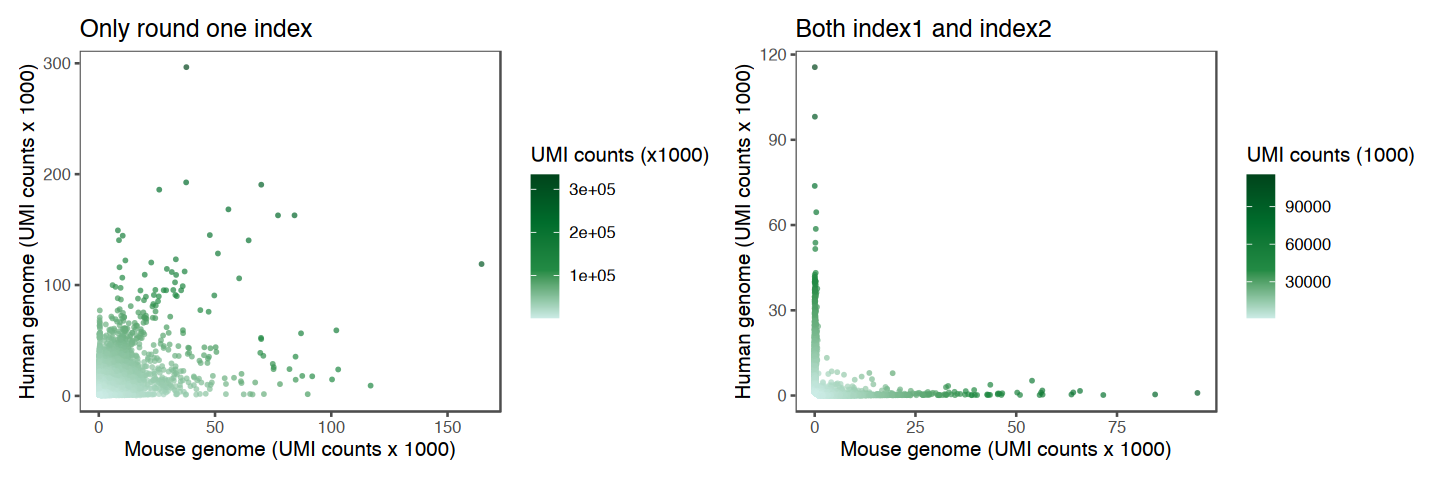

In [5]:
options(repr.plot.width = 12, repr.plot.height =4)
pp=p1+p2
print(pp)

Warning message:
"No shared levels found between `names(values)` of the manual scale and the
data's colour values."
Warning message:
"No shared levels found between `names(values)` of the manual scale and the
data's colour values."


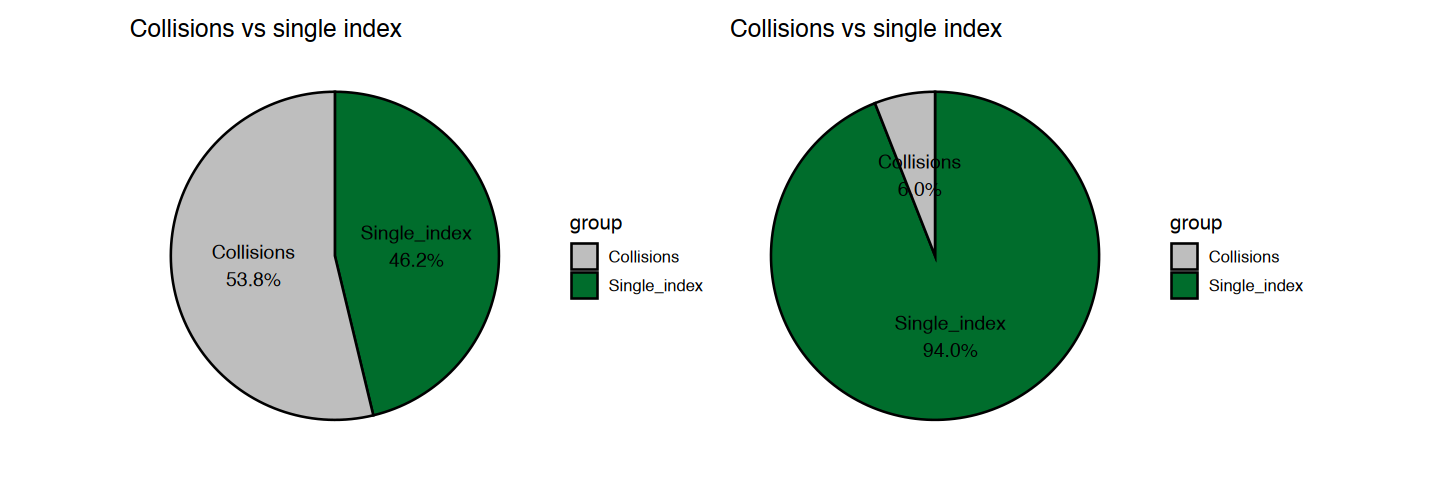

In [6]:
dropletlevel$Type="Collisions"
dropletlevel$Type[dropletlevel$ratio>0.85 |dropletlevel$ratio <0.15]="Single_index"
celldat$Type="Collisions"
celldat$Type[celldat$ratio>0.85 |celldat$ratio <0.15]="Single_index"
df_pie <- dropletlevel %>%
  filter(!is.na(Type)) %>%                                   
  mutate(group = if_else(Type == "Collisions",
                         "Collisions", "Single_index")) %>%
  count(group, name = "n") %>%                        
  mutate(prop  = n / sum(n),
         label = sprintf("%s\n%.1f%%", group, prop * 100)) %>%
  mutate(group = factor(group, levels = c("Collisions","Single_index")))

p1=ggpie(df_pie,
        x = "n", label = "label", fill = "group",
        lab.pos = "in", lab.font = c(4, "bold", "black"),
        palette = c("Collisions"     = "grey",
                    "Single_index" = '#006d2c'),
        title = "Collisions vs single index",
        legend = "right") 


df_pie <- celldat %>%
  filter(!is.na(Type)) %>%                                   # 可选：去掉缺失
  mutate(group = if_else(Type == "Collisions",
                         "Collisions", "Single_index")) %>%
  count(group, name = "n") %>%                               # ← 按行数汇总
  mutate(prop  = n / sum(n),
         label = sprintf("%s\n%.1f%%", group, prop * 100)) %>%
  mutate(group = factor(group, levels = c("Collisions","Single_index")))

p2=ggpie(df_pie,
        x = "n", label = "label", fill = "group",
        lab.pos = "in", lab.font = c(4, "bold", "black"),
        palette = c("Collisions"     = "grey",
                    "Single_index" = '#006d2c'),
        title = "Collisions vs single index",
        legend = "right")  +
  ggpubr::font("title", face = "bold")

pp=p1+p2
print(pp)


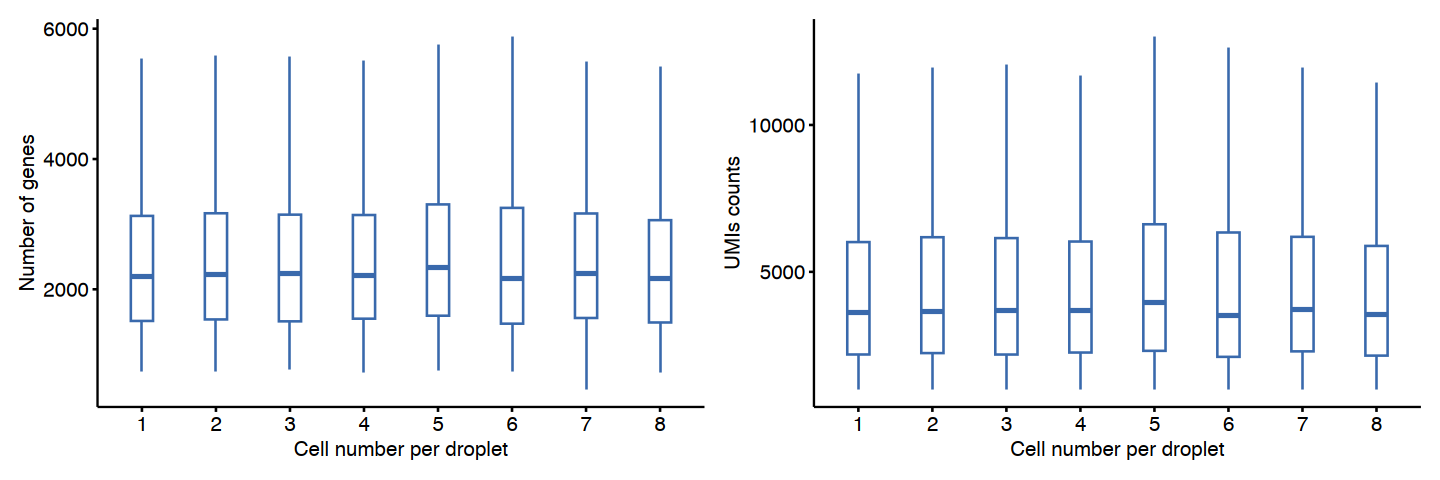

In [7]:
cellFeature=read.csv("human_gene_distribution.csv",header=T,row.names = 1,check.names = F)
p1=ggboxplot(cellFeature, x = "indexcounts", y = "genes",
             xlab = "Cell number per droplet",
             ylab ="Number of genes",
             repel=T,bxp.errorbar=F,outliers = FALSE,outlier.shape = NA, font.label = list(size = 12, color = "black"), width = 0.3,label.rectangle=F,legend='right', color="#3969AC",palette="igv")

p2=ggboxplot(cellFeature, x = "indexcounts", y = "umis",
             xlab = "Cell number per droplet",
             ylab ="UMIs counts",
             repel=T,bxp.errorbar=F,outliers = FALSE,outlier.shape = NA, font.label = list(size = 12, color = "black"), width = 0.3,label.rectangle=F,legend='right', color="#3969AC",palette="igv")

pp=p1+p2
print(pp)


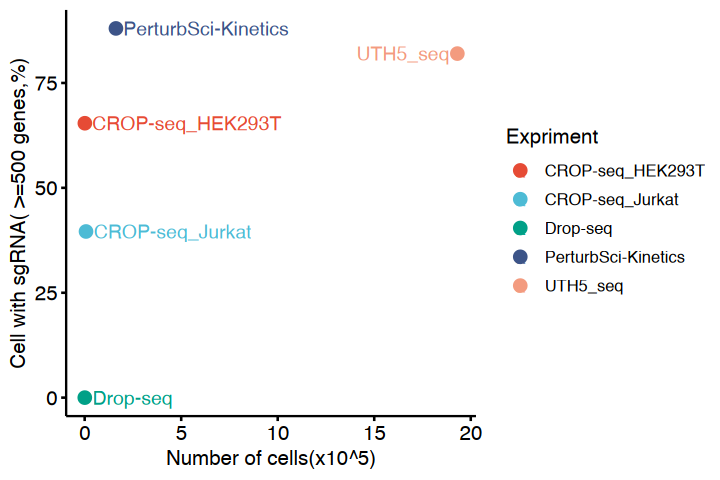

In [8]:
options(repr.plot.width = 6, repr.plot.height =4)
techidat<-read.table("gRNA_cells.txt",header = T,sep="\t")
techidat$cellnum=techidat$cells/100000
pp=ggscatter(techidat,x="cellnum",
             y="percent",
             fill = "Expriment",color = "Expriment",
             palette = "npg",
             repel = T,
             legend='right',
             label = "Expriment",
             label.select = techidat$Expriment,
             xlab="Number of cells(x10^5)",
             ylab="Cell with sgRNA( >=500 genes,%)",
             size = 3)
print(pp)

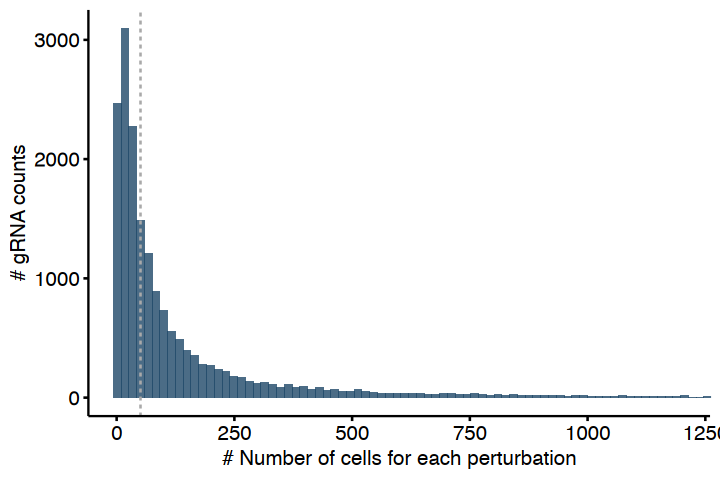

In [ ]:
dat<-readRDS("dat.rds")
per_cell_df <- dat@meta.data[, c("cell_new_name", "Pertubation")]
cell_pert_df <- separate_rows(per_cell_df, Pertubation, sep = ":")
cell_pert_df <- data.frame(cell_pert_df)
cell_pert_df <- unique(cell_pert_df)

pt_cell_num <- data.frame(table(cell_pert_df$Pertubation))
colnames(pt_cell_num) <- c("perturbation", "cells")
p=gghistogram(
  pt_cell_num,
  x = "cells",
  bins = 20000,
  xlim = c(0, 1200),
  xlab = "# Number of cells for each perturbation",
  ylab = "# gRNA counts",
  col = NA,
  fill = "#1E4768",
  alpha = 0.8
) +geom_vline(xintercept = c(50), 
              linetype = "dashed", 
              color = "darkgrey")
print(p)